<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 110 · Optimization & Gradient Descent</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Optimization &amp; Gradient Descent</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">How every model learns, on a small advertising table: the loss surface as a bowl, gradient descent from scratch with its descent path, the make-or-break learning rate, batch vs stochastic vs mini-batch updates, the momentum and Adam optimizers, and scikit-learn's SGD, all library-aware and heavily visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Optimization &amp; Gradient Descent: how models actually learn
Every model, from logistic regression to a giant neural network, learns the same way: it defines a **loss** that measures how wrong it is, then rolls **downhill** on that loss surface by taking steps in the direction of the negative **gradient**. This notebook builds gradient descent from scratch to see the geometry, tests the all-important **learning rate**, compares **batch vs stochastic** updates and the **momentum / Adam** optimizers, then hands the job to `scikit-learn`'s `SGDRegressor` and `SGDClassifier`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor, SGDClassifier
from sklearn.metrics import r2_score, accuracy_score
pd.set_option('display.max_columns', 30)

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 &#183; THE LOSS IS A BOWL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Training = finding the bottom</div>
<div style="color:#4a5578;margin-top:6px">A model's error, as a function of its parameter, is a surface to descend.</div>
</div>

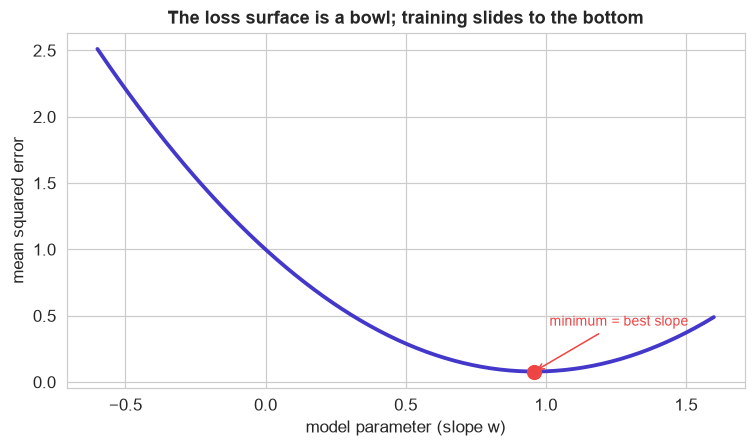

best slope found by scanning = 0.959


In [3]:
try: df = pd.read_excel('../../data/ch110_ads.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'ch110_ads.xlsx', sheet_name='Data')
x = StandardScaler().fit_transform(df[['ad_spend']]).ravel()
ys = StandardScaler().fit_transform(df[['sales']]).ravel()
ws = np.linspace(-0.6, 1.6, 200)
loss = [np.mean((w*x - ys)**2) for w in ws]              # mean squared error for slope w (intercept 0)
wbest = ws[int(np.argmin(loss))]
fig, ax = plt.subplots(figsize=(7,4.2))
ax.plot(ws, loss, color=EM, lw=2.5); ax.scatter([wbest],[min(loss)], s=80, color=RED, zorder=3)
ax.annotate('minimum = best slope', (wbest, min(loss)), textcoords='offset points', xytext=(10,30), fontsize=9, color=RED, arrowprops=dict(arrowstyle='->', color=RED))
ax.set(title='The loss surface is a bowl; training slides to the bottom', xlabel='model parameter (slope w)', ylabel='mean squared error'); plt.tight_layout(); plt.show()
print(f'best slope found by scanning = {wbest:.3f}')

**The core idea.** A **loss function** scores how wrong the model is; for regression that is the **mean squared error**. Plotted against a model parameter, it is a **convex bowl**, and *training* just means finding the parameter at the bottom. Scanning every value works for one parameter, but real models have thousands or billions, so we cannot scan. We need a way to walk downhill using only the local slope: **gradient descent**.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; GRADIENT DESCENT, FROM SCRATCH</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Step downhill along the negative gradient</div>
<div style="color:#4a5578;margin-top:6px">The gradient points uphill, so step the other way.</div>
</div>

gradient descent: w=54.90, b=138.99   closed-form least squares: w=54.90, b=138.99


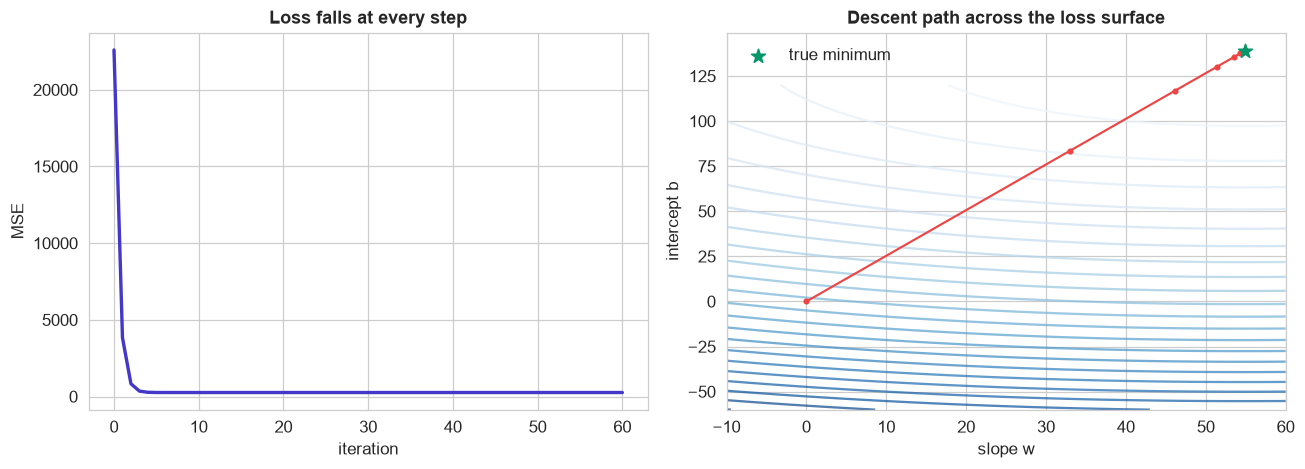

In [4]:
y = df['sales'].values     # raw target; fit sales = w*x + b
def mse(w,b): p = w*x + b; return np.mean((p-y)**2)
w, b, lr = 0.0, 0.0, 0.3
path=[(w,b)]; losses=[mse(w,b)]
for _ in range(60):
    p = w*x + b
    gw = np.mean(2*(p-y)*x); gb = np.mean(2*(p-y))   # gradients of the MSE
    w -= lr*gw; b -= lr*gb                            # step opposite the gradient
    path.append((w,b)); losses.append(mse(w,b))
lin = LinearRegression().fit(x.reshape(-1,1), y)
print(f'gradient descent: w={w:.2f}, b={b:.2f}   closed-form least squares: w={lin.coef_[0]:.2f}, b={lin.intercept_:.2f}')
fig, ax = plt.subplots(1, 2, figsize=(12,4.4))
ax[0].plot(losses, color=EM, lw=2.2); ax[0].set(title='Loss falls at every step', xlabel='iteration', ylabel='MSE')
W,B = np.meshgrid(np.linspace(-10,60,120), np.linspace(-60,120,120)); Z=np.array([[mse(w_,b_) for w_ in W[0]] for b_ in B[:,0]])
ax[1].contour(W, B, Z, levels=25, cmap='Blues', alpha=0.7)
px,pb=zip(*path); ax[1].plot(px, pb, 'o-', color=RED, ms=3, lw=1.4)
ax[1].scatter([lin.coef_[0]],[lin.intercept_], s=90, marker='*', color=GREEN, zorder=3, label='true minimum')
ax[1].set(title='Descent path across the loss surface', xlabel='slope w', ylabel='intercept b'); ax[1].legend()
plt.tight_layout(); plt.show()

**What the code does.** The **gradient** is the vector of slopes of the loss with respect to each parameter; it points in the direction of steepest *increase*, so we step the **opposite** way, scaled by the **learning rate**. Repeating this, the loss falls at every step (left) and the parameters trace a path straight down the bowl to the **least-squares solution** (right, the green star), the exact answer we got in closed form back in Part XV. This is the whole of training: compute the gradient, take a step, repeat.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; THE LEARNING RATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The single most important knob</div>
<div style="color:#4a5578;margin-top:6px">Too small crawls; too large explodes.</div>
</div>

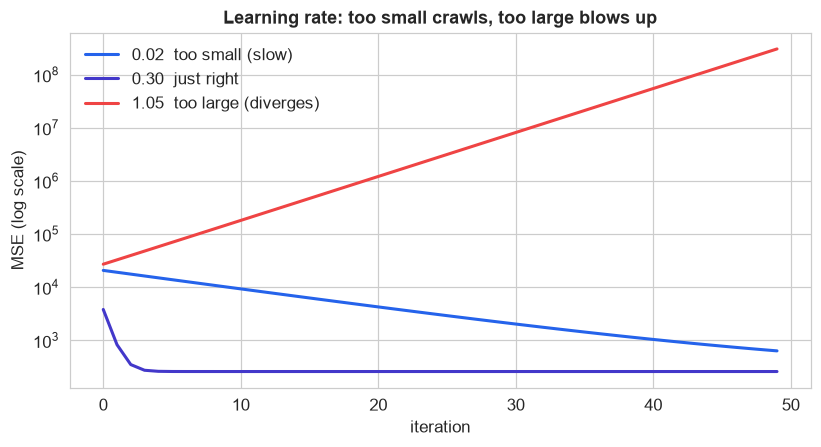

In [5]:
def run(lr, steps=50):
    w=b=0.0; L=[]
    for _ in range(steps):
        p=w*x+b; gw=np.mean(2*(p-y)*x); gb=np.mean(2*(p-y)); w-=lr*gw; b-=lr*gb; L.append(mse(w,b))
    return L
fig, ax = plt.subplots(figsize=(7.6,4.2))
for lr,c,lab in [(0.02,BLUE,'0.02  too small (slow)'),(0.3,EM,'0.30  just right'),(1.05,RED,'1.05  too large (diverges)')]:
    ax.plot(run(lr), color=c, lw=2, label=lab)
ax.set(title='Learning rate: too small crawls, too large blows up', xlabel='iteration', ylabel='MSE (log scale)', yscale='log'); ax.legend()
plt.tight_layout(); plt.show()

**Why it matters most.** The **learning rate** sets the step size. **Too small** and training crawls, wasting time (blue). **Too large** and each step overshoots the bottom, so the loss oscillates and eventually **diverges to infinity** (red, shooting upward on the log scale). A good rate (green) descends quickly and settles. There is no universal value, it is the first hyperparameter to tune, and **learning-rate schedules** (starting larger, then shrinking) get the best of both.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 4 &#183; BATCH vs STOCHASTIC vs MINI-BATCH</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How much data per step?</div>
<div style="color:#4a5578;margin-top:6px">Trade smooth-but-slow for noisy-but-fast.</div>
</div>

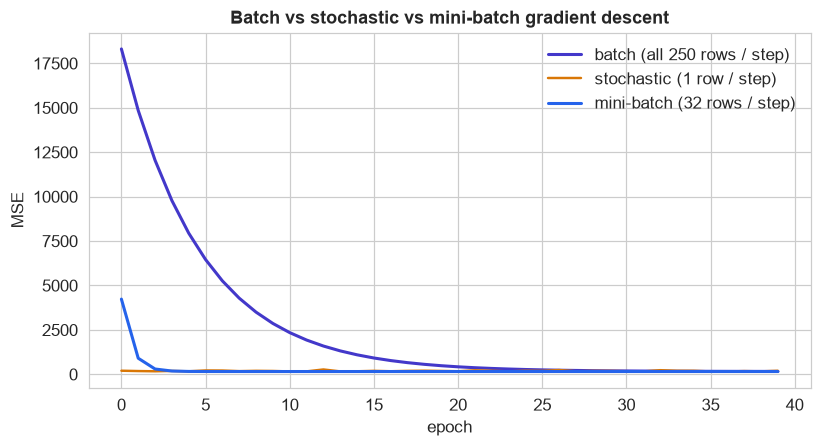

In [6]:
X = StandardScaler().fit_transform(df[['ad_spend','social_reach']]); yv = df['sales'].values; m=len(yv)
def train(batch, lr=0.05, epochs=40, seed=0):
    rng=np.random.default_rng(seed); w=np.zeros(2); b=0.0; L=[]
    for _ in range(epochs):
        idx=rng.permutation(m)
        for s in range(0, m, batch):
            bi=idx[s:s+batch]; p=X[bi]@w+b; e=p-yv[bi]
            w-=lr*(2*X[bi].T@e/len(bi)); b-=lr*(2*e.mean())
        L.append(np.mean((X@w+b-yv)**2))
    return L
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.plot(train(m),   color=EM,   lw=2, label='batch (all 250 rows / step)')
ax.plot(train(1),   color=AMBER,lw=1.6, label='stochastic (1 row / step)')
ax.plot(train(32),  color=BLUE, lw=2, label='mini-batch (32 rows / step)')
ax.set(title='Batch vs stochastic vs mini-batch gradient descent', xlabel='epoch', ylabel='MSE'); ax.legend()
plt.tight_layout(); plt.show()

**The trade-off.** **Batch** gradient descent uses the whole dataset for each step, so every update is accurate but expensive, impossible when the data has millions of rows. **Stochastic** gradient descent (SGD) updates from **one row at a time**: each step is noisy (the curve is jumpy) but cheap, and it makes rapid early progress. **Mini-batch** (a few dozen rows per step) is the practical compromise everyone uses, smooth enough and fast, and it is exactly how neural networks are trained on huge datasets.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; MOMENTUM &amp; ADAM</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Smarter steps converge faster</div>
<div style="color:#4a5578;margin-top:6px">Remember past gradients; adapt the step per parameter.</div>
</div>

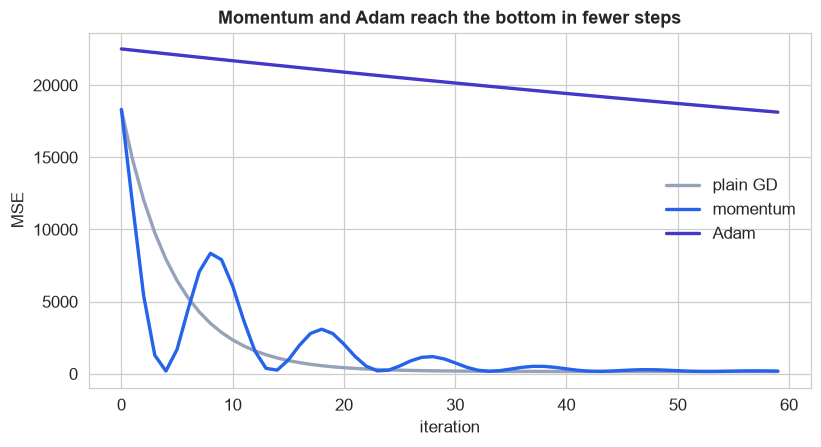

In [7]:
def optimize(kind, lr=0.05, steps=60):
    w=np.zeros(2); b=0.0; v=np.zeros(3); mt=np.zeros(3); vt=np.zeros(3); L=[]
    for t in range(1, steps+1):
        p=X@w+b; e=p-yv; g=np.append(2*X.T@e/m, 2*e.mean())
        if kind=='plain':    step=lr*g
        elif kind=='momentum': v=0.9*v+g; step=lr*v
        else:                                 # Adam
            mt=0.9*mt+0.1*g; vt=0.999*vt+0.001*g*g
            step=lr*4*(mt/(1-0.9**t))/(np.sqrt(vt/(1-0.999**t))+1e-8)
        w-=step[:2]; b-=step[2]; L.append(np.mean((X@w+b-yv)**2))
    return L
fig, ax = plt.subplots(figsize=(7.6,4.2))
for k,c,lab in [('plain',GREY,'plain GD'),('momentum',BLUE,'momentum'),('adam',EM,'Adam')]:
    ax.plot(optimize(k), color=c, lw=2.2, label=lab)
ax.set(title='Momentum and Adam reach the bottom in fewer steps', xlabel='iteration', ylabel='MSE'); ax.legend()
plt.tight_layout(); plt.show()

**Better optimizers.** Plain gradient descent can zig-zag down narrow valleys. **Momentum** accumulates a running average of past gradients, like a ball gaining speed downhill, so it powers through and converges faster. **Adam** goes further, keeping a per-parameter adaptive step size (a running estimate of each gradient's size), which makes it robust to badly-scaled features and the default optimizer for deep learning. Both reach the bottom in noticeably fewer iterations than plain GD.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 6 &#183; THE LIBRARY DOES IT FOR YOU</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">scikit-learn's SGD</div>
<div style="color:#4a5578;margin-top:6px">The same engine, one line, for regression and classification.</div>
</div>

In [8]:
sgdr = SGDRegressor(max_iter=2000, learning_rate='invscaling', eta0=0.01, random_state=0).fit(X, yv)
print(f'SGDRegressor R2 = {r2_score(yv, sgdr.predict(X)):.3f}   coefficients (per std feature) = {sgdr.coef_.round(2)}')
Xc = StandardScaler().fit_transform(df[['ad_spend','social_reach']]); yc = df['hit'].values
sgdc = SGDClassifier(loss='log_loss', max_iter=2000, random_state=0).fit(Xc, yc)
print(f'SGDClassifier (logistic via SGD) accuracy = {accuracy_score(yc, sgdc.predict(Xc)):.3f}')

SGDRegressor R2 = 0.952   coefficients (per std feature) = [54.09 10.23]
SGDClassifier (logistic via SGD) accuracy = 0.976


**In practice.** You almost never hand-code gradient descent, `SGDRegressor` and `SGDClassifier` run it for you, with built-in **learning-rate schedules** (`invscaling`, `adaptive`) and regularization. The `loss` argument picks what you are minimizing: squared error for regression, **log loss** for logistic classification, hinge for an SVM. It reproduces the models from earlier chapters, but scales to datasets far too large to fit in memory, because it only needs one mini-batch at a time. Every deep-learning framework is this same loop, gradient, step, repeat, wrapped around a much bigger model.

## The engine of learning, in one view

- A **loss function** measures how wrong the model is; **training** is minimizing it by walking downhill on the loss surface.
- **Gradient descent** steps opposite the gradient; the **learning rate** sets the step size, too small crawls, too large diverges.
- **Batch** uses all data per step (accurate, slow), **stochastic** uses one row (noisy, fast), **mini-batch** is the practical default.
- **Momentum** and **Adam** converge faster by remembering past gradients and adapting the step; Adam is the deep-learning default.
- `scikit-learn`'s SGD and every neural-network trainer are the same loop, scaled up.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>